# ASSIGNMENT NLP – 5  
## POS Tagging with BERT on UD English Dataset

---

### Objective  
Train and evaluate a BERT-based sequence labeling model for **Part-of-Speech (POS) tagging** on a real-world dependency treebank, using a token-level classification setup and standard sequence labeling metrics.

---

### Dataset Used  
- **Source Hub:** Hugging Face Datasets  
- **Dataset:** XTREME – Universal Dependencies POS (UDPOS)  
- **Configuration:** `udpos.English` (English treebank)  
- **Input:** Sentences as tokenized word sequences (`tokens`)  
- **Labels:** POS tags for each token (`pos_tags`) with 17 universal tag types (e.g., NOUN, VERB, ADJ, ADV, PROPN, PRON, etc.)  
- **Task Type:** Token-level sequence labeling (assign one POS tag to each word in the sentence)

---

### Model Used  
- **Base Transformer:** `bert-base-cased`  
- **Architecture:** `AutoModelForTokenClassification`  
  - Single classification head on top of the BERT encoder  
  - Number of output neurons = number of POS tag classes  
- **Label Handling Strategy:**  
  - WordPiece tokenization with `is_split_into_words=True`  
  - Gold POS label assigned to the **first subword** of each original word  
  - All continuation subwords and special tokens (`[CLS]`, `[SEP]`) are masked with `-100` so they are ignored by the loss function  

---

### Tools and Technologies  
- Python  
- Hugging Face Transformers  
- Hugging Face Datasets  
- PyTorch  
- `seqeval` + `evaluate` for sequence labeling metrics  
- NumPy & Matplotlib for basic EDA and label distribution plots  
- Google Colab (GPU runtime) / Jupyter Notebook  

---

### Inference and Practical Usage  
- Implemented a `predict(sentence)` helper function that:  
  - Splits an input sentence into whitespace-separated tokens  
  - Applies BERT + token classification head to obtain logits per token  
  - Decodes predicted IDs back to human-readable POS tag names  
  - Returns a clear table mapping each `Token` to its predicted `POS Tag` for easy inspection and qualitative analysis  

In [1]:
!pip install -q transformers datasets seqeval evaluate accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.6 MB/s eta 0:00:00


In [3]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModel,
    TrainingArguments, Trainer
)
import evaluate
import torch.nn as nn
from torch.nn import CrossEntropyLoss
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [5]:
dataset = load_dataset("xtreme", "udpos.English")
print(dataset)

README.md: 0.00B [00:00, ?B/s]

udpos.English/train-00000-of-00001.parqu(…):   0%|          | 0.00/1.48M [00:00<?, ?B/s]

udpos.English/validation-00000-of-00001.(…):   0%|          | 0.00/265k [00:00<?, ?B/s]

udpos.English/test-00000-of-00001.parque(…):   0%|          | 0.00/367k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/21253 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3974 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5440 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['tokens', 'pos_tags'],
        num_rows: 21253
    })
    validation: Dataset({
        features: ['tokens', 'pos_tags'],
        num_rows: 3974
    })
    test: Dataset({
        features: ['tokens', 'pos_tags'],
        num_rows: 5440
    })
})


In [6]:
example = dataset["train"][0]
print(example)

{'tokens': ['Aesthetic', 'Appreciation', 'and', 'Spanish', 'Art', ':'], 'pos_tags': [0, 7, 4, 0, 7, 12]}


In [9]:
print(dataset["train"].features)

pos_feature = "pos_tags"   # <- use this
pos_label_list = dataset["train"].features[pos_feature].feature.names

id2label_pos = {i: l for i, l in enumerate(pos_label_list)}
label2id_pos = {l: i for i, l in enumerate(pos_label_list)}
num_pos_labels = len(pos_label_list)

print(f"Number of POS labels: {num_pos_labels}")
print("POS labels:", pos_label_list)

{'tokens': List(Value('string')), 'pos_tags': List(ClassLabel(names=['ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'INTJ', 'NOUN', 'NUM', 'PART', 'PRON', 'PROPN', 'PUNCT', 'SCONJ', 'SYM', 'VERB', 'X']))}
Number of POS labels: 17
POS labels: ['ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'INTJ', 'NOUN', 'NUM', 'PART', 'PRON', 'PROPN', 'PUNCT', 'SCONJ', 'SYM', 'VERB', 'X']


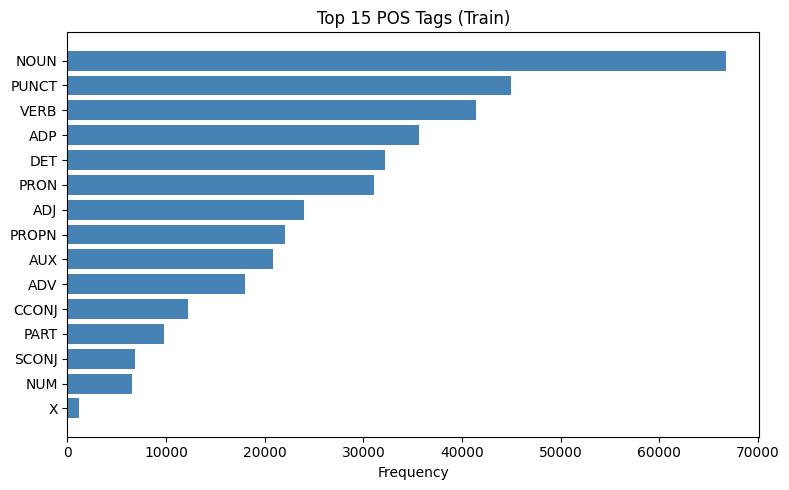

In [10]:
from collections import Counter
import matplotlib.pyplot as plt

all_pos = [id2label_pos[t] for ex in dataset["train"] for t in ex[pos_feature]]
top_pos = Counter(all_pos).most_common(15)

plt.figure(figsize=(8, 5))
plt.barh([x[0] for x in top_pos], [x[1] for x in top_pos], color="steelblue")
plt.gca().invert_yaxis()
plt.title("Top 15 POS Tags (Train)")
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()

In [11]:
from transformers import AutoTokenizer

MODEL_NAME = "bert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_and_align_labels(examples):
    # Tokenize list of tokens
    tokenized = tokenizer(
        examples["tokens"],              # list of words
        is_split_into_words=True,
        truncation=True,
        max_length=128,
    )

    all_labels = []

    for i, pos_tags in enumerate(examples[pos_feature]):   # pos_feature = "pos_tags"
        word_ids = tokenized.word_ids(batch_index=i)
        prev_word_id = None
        labels = []

        for word_id in word_ids:
            if word_id is None:
                # Special tokens -> ignore
                labels.append(-100)
            elif word_id != prev_word_id:
                # First subword of a word -> real label
                labels.append(pos_tags[word_id])
            else:
                # Continuation subword -> ignore
                labels.append(-100)
            prev_word_id = word_id

        all_labels.append(labels)

    tokenized["labels"] = all_labels   # Trainer expects "labels"
    return tokenized

tokenized_dataset = dataset.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=dataset["train"].column_names,
)

print("Tokenization & label alignment done.")
print("Features:", tokenized_dataset["train"].features)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/21253 [00:00<?, ? examples/s]

Map:   0%|          | 0/3974 [00:00<?, ? examples/s]

Map:   0%|          | 0/5440 [00:00<?, ? examples/s]

Tokenization & label alignment done.
Features: {'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8')), 'labels': List(Value('int64'))}


In [12]:
ex = tokenized_dataset["train"][0]
tokens = tokenizer.convert_ids_to_tokens(ex["input_ids"])

print(f"{'Token':<20} {'Label'}")
print("-" * 32)
for tok, lab in zip(tokens, ex["labels"]):
    label_str = id2label_pos[lab] if lab != -100 else "-100 (ignored)"
    print(f"{tok:<20} {label_str}")

Token                Label
--------------------------------
[CLS]                -100 (ignored)
A                    ADJ
##est                -100 (ignored)
##hetic              -100 (ignored)
A                    NOUN
##pp                 -100 (ignored)
##re                 -100 (ignored)
##ciation            -100 (ignored)
and                  CCONJ
Spanish              ADJ
Art                  NOUN
:                    PUNCT
[SEP]                -100 (ignored)


In [13]:
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_pos_labels,
    id2label=id2label_pos,
    label2id=label2id_pos,
)

model.to(device)
print("Model loaded on", device)

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

Model loaded on cuda


In [14]:
from transformers import DataCollatorForTokenClassification
import evaluate
import numpy as np

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)
seqeval = evaluate.load("seqeval")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    true_preds, true_labels = [], []
    for pred_seq, label_seq in zip(preds, labels):
        p_row, l_row = [], []
        for p, l in zip(pred_seq, label_seq):
            if l != -100:
                p_row.append(id2label_pos[p])
                l_row.append(id2label_pos[l])
        true_preds.append(p_row)
        true_labels.append(l_row)

    result = seqeval.compute(predictions=true_preds, references=true_labels)
    return {
        "precision": round(result["overall_precision"], 4),
        "recall":    round(result["overall_recall"],    4),
        "f1":        round(result["overall_f1"],        4),
        "accuracy":  round(result["overall_accuracy"],  4),
    }

In [17]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./bert_pos_ud",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=5e-5,
    weight_decay=0.01,
    logging_steps=50,
    report_to="none",
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Step,Training Loss
50,1.077016
100,0.237573
150,0.183701
200,0.168709
250,0.161876
300,0.158499
350,0.168977
400,0.138384
450,0.140745
500,0.141332


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3987, training_loss=0.09285906693497067, metrics={'train_runtime': 545.1604, 'train_samples_per_second': 116.955, 'train_steps_per_second': 7.313, 'total_flos': 1794168509716998.0, 'train_loss': 0.09285906693497067, 'epoch': 3.0})

In [18]:
results = trainer.evaluate(tokenized_dataset["test"])

print("Test set performance:")
for k, v in results.items():
    if k.startswith("eval_"):
        print(f"{k}: {v:.4f}")

Test set performance:
eval_loss: 0.1372
eval_precision: 0.9573
eval_recall: 0.9577
eval_f1: 0.9575
eval_accuracy: 0.9637
eval_runtime: 14.6404
eval_samples_per_second: 371.5750
eval_steps_per_second: 11.6120


In [19]:
def predict(sentence: str) -> pd.DataFrame:
    model.eval()
    words = sentence.split()

    encoded = tokenizer(
        words,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True,
        max_length=128,
    ).to(device)

    with torch.no_grad():
        outputs = model(**encoded)

    preds = torch.argmax(outputs.logits, dim=-1)[0].cpu().numpy()
    word_ids = encoded.word_ids(batch_index=0)

    rows, seen = [], set()
    for idx, wid in enumerate(word_ids):
        if wid is not None and wid not in seen:
            rows.append({
                "Token":  words[wid],
                "POS Tag": id2label_pos[preds[idx]],
            })
            seen.add(wid)

    return pd.DataFrame(rows)

# Example sentences
s1 = "John works at Google in California"
print(f"Input: {s1}\n")
print(predict(s1).to_string(index=False))

s2 = "The quick brown fox jumps over the lazy dog"
print(f"\nInput: {s2}\n")
print(predict(s2).to_string(index=False))

Input: John works at Google in California

     Token POS Tag
      John   PROPN
     works    VERB
        at     ADP
    Google   PROPN
        in     ADP
California   PROPN

Input: The quick brown fox jumps over the lazy dog

Token POS Tag
  The     DET
quick     ADJ
brown     ADJ
  fox    NOUN
jumps    VERB
 over     ADP
  the     DET
 lazy     ADJ
  dog    NOUN
